Supernova

In [ ]:
!pip install emcee
!pip install corner
!pip install astropy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
import astropy.units as u
import astropy.constants as c
from astropy.cosmology import FlatLambdaCDM, LambdaCDM, FlatwCDM
import pandas as pd

In [ ]:
data_path="/content/Pantheon+SH0ES.dat"
cov_path="/content/Pantheon+SH0ES_STATONLY.cov"
#Cargamos datos Pantheon y la matriz de covarianza

In [ ]:
data_original=pd.read_csv(data_path,sep=r'\s+', comment='#')
print(data_original.shape)
data_original.head()
#Leeemos datos y vemos  como se dividen

(1701, 47)


,CID,IDSURVEY,zHD,zHDERR,zCMB,zCMBERR,zHEL,zHELERR,m_b_corr,m_b_corr_err_DIAG,...,PKMJDERR,NDOF,FITCHI2,FITPROB,m_b_corr_err_RAW,m_b_corr_err_VPEC,biasCor_m_b,biasCorErr_m_b,biasCor_m_b_COVSCALE,biasCor_m_b_COVADD
0,2011fe,51,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.74571,1.516210,...,0.1071,36,26.8859,0.864470,0.0991,1.4960,0.0381,0.005,1.0,0.003
1,2011fe,56,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.80286,1.517230,...,0.0579,101,88.3064,0.812220,0.0971,1.4960,-0.0252,0.003,1.0,0.004
2,2012cg,51,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.47030,0.781906,...,0.0278,165,233.5000,0.000358,0.0399,0.7134,0.0545,0.019,1.0,0.036
3,2012cg,56,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.49190,0.798612,...,0.0667,55,100.1220,0.000193,0.0931,0.7134,0.0622,0.028,1.0,0.040
4,1994DRichmond,50,0.00299,0.00084,0.00299,0.00004,0.00187,0.00004,11.52270,0.880798,...,0.0522,146,109.8390,0.988740,0.0567,0.6110,0.0650,0.009,1.0,0.006


In [ ]:
#Ahora leemos la matriz de covarianza
with open(cov_path, "r") as f:
    N = int(f.readline())
    cov_values = np.loadtxt(f)

print("N =", N)
print("Elementos leídos =", len(cov_values))
print("Elementos esperados =", N*N)

cov_original = cov_values.reshape((N, N))

print(cov_original.shape)


N = 1701
Elementos leídos = 2893401
Elementos esperados = 2893401
(1701, 1701)


In [ ]:
#Quitamos los shoes
mask = data_original['IS_CALIBRATOR'] == 0
data=data_original[mask].reset_index(drop=True)
indices=np.where(mask)[0]
cov= cov_original[np.ix_(indices,indices)]
print('Numero de datos:', len(data))
print('Tamaño matriz filtrada:', cov.shape)

Numero de datos: 1624
Tamaño matriz filtrada: (1624, 1624)


In [ ]:
#Variables
z=data['zHD'].values
mb=data['mB'].values
x1=data['x1'].values
c=data['c'].values
bias=data['biasCor_m_b'].values

# Error diagonal solo para graficar
mu_err_diag=np.sqrt(np.diag(cov))

print("z:", z[:5])
print("m_b:", mb[:5])
print("x1:", x1[:5])
print("c:", c[:5])
print("bias:", bias[:5])
print("error diagonal:", mu_err_diag[:5])

z: [0.00299 0.00482 0.00483 0.00483 0.00483]
m_b: [11.5334 12.1471 12.7485 12.2736 12.8139]
x1: [-1.61803 -1.1428  -2.22068 -1.67481 -2.28189]
c: [-0.111684 -0.010995  0.003067 -0.029989 -0.018119]
bias: [ 0.065  -0.0345 -0.0405 -0.0201 -0.0296]
error diagonal: [0.6203     0.3931     0.4037     0.1607233  0.11284671]


1.Inferencia de parámetros para un universo LCDM sin curvatura

In [ ]:
#Definimos al modelo
#Fijamos el valor de H0 a un valor cercano al de la tabla del paper
H0_fijo= 67.0
 #Ahora para calcular los parametros de distancia utilizamos la libreria astropy,
 # etse tiene funciones que calcula internamente:
 # d_L(z) = (1+z)c ∫ dz'/H(z')
    #
    # y después el módulo de distancia:
    #
    # mu = 5 log10(d_L / 10 pc)
    #
    # usando la cosmología Flat ΛCDM
    #Entonces definiomos
def modelo_flat_LCDM(z, Omega_M):
  cosmo = FlatLambdaCDM(H0=H0_fijo, Om0=Omega_M)
  mu_model= cosmo.distmod(z).value
  return mu_model
def mu_obs_tripp(alpha, beta, M):
  mu_obs=(mb + alpha*x1 - beta*c - M - bias)
  return mu_obs

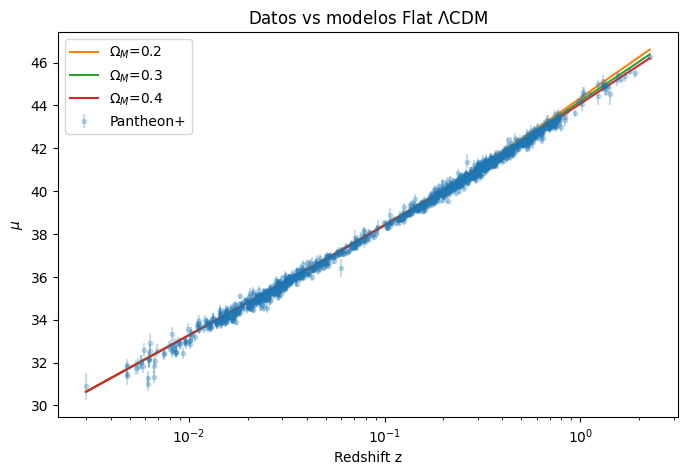

In [ ]:
z_grid=np.linspace(z.min(), z.max(),500)

plt.figure(figsize=(8,5))

#Ponemos de referencia
alpha_ref=0.14
beta_ref=3.1
M_ref=-19.3

mu_obs_ref=mu_obs_tripp(alpha_ref, beta_ref, M_ref)
plt.errorbar(z, mu_obs_ref, yerr=mu_err_diag, fmt='.', alpha=0.25, label='Pantheon+')
for Om in [0.2,0.3,0.4]:
  plt.plot(z_grid, modelo_flat_LCDM(z_grid, Om), label=f'$\\Omega_M$={Om}')

plt.xscale("log")
plt.xlabel("Redshift z")
plt.ylabel(r"$\mu$")
plt.title("Datos vs modelos Flat $\\Lambda$CDM")
plt.legend()
plt.show()

In [ ]:
#Invertimos ahora la matriz de covarianza
cov_inv= np.linalg.inv(cov)

In [ ]:
#Ahora definimos os priors
def log_prior(theta):
  Omega_M, alpha, beta, M = theta

  if (0.01 < Omega_M < 1 and -25< M < -15 and 0.0<alpha<0.5 and 1.0<beta< 5.0):
    return 0.0
  return -np.inf

In [ ]:
#Hacemos likelihood con la matriz de covarianza
def log_likelihood(theta, z, cov_inv):
  Omega_M, alpha, beta, M = theta
  #Distancias obsevadas
  mu_obs=mu_obs_tripp(alpha, beta, M)
  #Distancia predicha por el modelo cosmologico
  mu_model = modelo_flat_LCDM(z, Omega_M)
  delta= mu_obs - mu_model
  chi2=delta.T @ cov_inv @ delta
  return  -0.5*chi2



In [ ]:
#Segimos con el posterior
def log_probability(theta, z, cov_inv):
  lp = log_prior(theta)
  if not np.isfinite(lp):
    return -np.inf
  return lp + log_likelihood(theta, z, cov_inv)

In [ ]:
#Configuramos el MCMC
ndim=4
nwalker= 32
nsteps= 3000

theta_inicial= np.array([0.3, 0.14, 3.1, -19.3])


pos= theta_inicial + 1e-3*np.random.randn(nwalker, ndim)
sampler= emcee.EnsembleSampler(nwalker, ndim, log_probability, args=(z, cov_inv))

sampler.run_mcmc(pos, nsteps, progress=True)




100%|██████████| 3000/3000 [57:30<00:00,  1.15s/it]


State([[  0.32802572   0.15032436   3.08590979 -19.39218735]
 [  0.34366933   0.14898988   3.22063217 -19.38537664]
 [  0.31239232   0.14663275   3.04916744 -19.40258279]
 [  0.34688256   0.14480761   3.0981556  -19.38891682]
 [  0.34398197   0.14913528   3.11317804 -19.39213916]
 [  0.33570247   0.15251044   3.0549725  -19.39522237]
 [  0.35056053   0.14535498   3.13936397 -19.38261483]
 [  0.33744466   0.14863635   3.20047883 -19.38735839]
 [  0.34543728   0.14990382   3.12329789 -19.385532  ]
 [  0.32299578   0.14763283   3.13795804 -19.39590774]
 [  0.35212845   0.14835321   3.11659851 -19.38382598]
 [  0.34194176   0.14842434   3.02343595 -19.40107736]
 [  0.34244642   0.14922774   3.08099588 -19.39469003]
 [  0.35780738   0.1457735    3.11834007 -19.38366383]
 [  0.35544457   0.14871133   3.13058869 -19.3800577 ]
 [  0.33121527   0.14768907   3.15849361 -19.39329283]
 [  0.35233721   0.15370583   3.12274389 -19.38426486]
 [  0.34142363   0.15535223   3.07202932 -19.38855471]
 [  

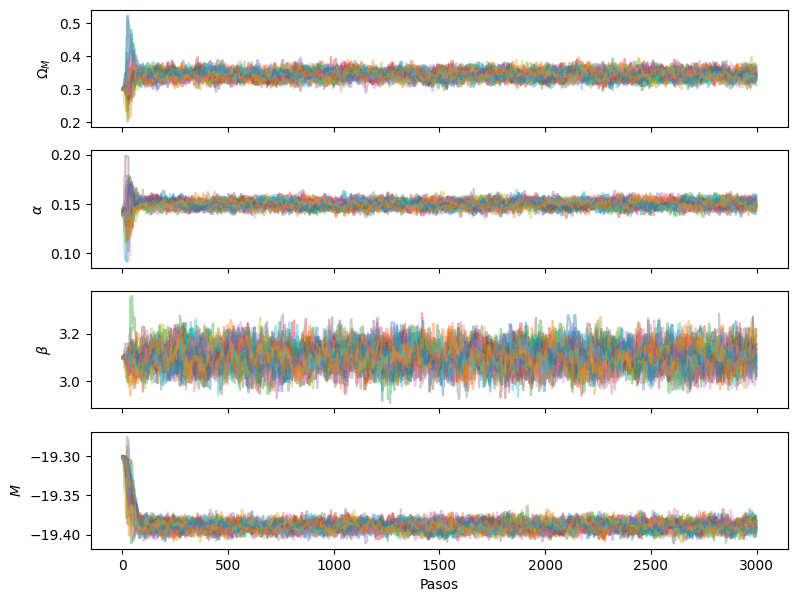

In [ ]:
#Graficamos las cadenas

samples_chain=sampler.get_chain()
labels=[r"$\Omega_M$",
    r"$\alpha$",
    r"$\beta$",
    r"$M$"]

fig,axes = plt.subplots(ndim, figsize=(9,7), sharex=True)

for i in range(ndim):
  axes[i].plot(samples_chain[:,:,i],  alpha=0.4)
  axes[i].set_ylabel(labels[i])
axes[-1].set_xlabel("Pasos")
plt.show()

#Aplanamos las cadenas
#flat_samples = sampler.get_chain(discard=500, thin=10, flat=True)


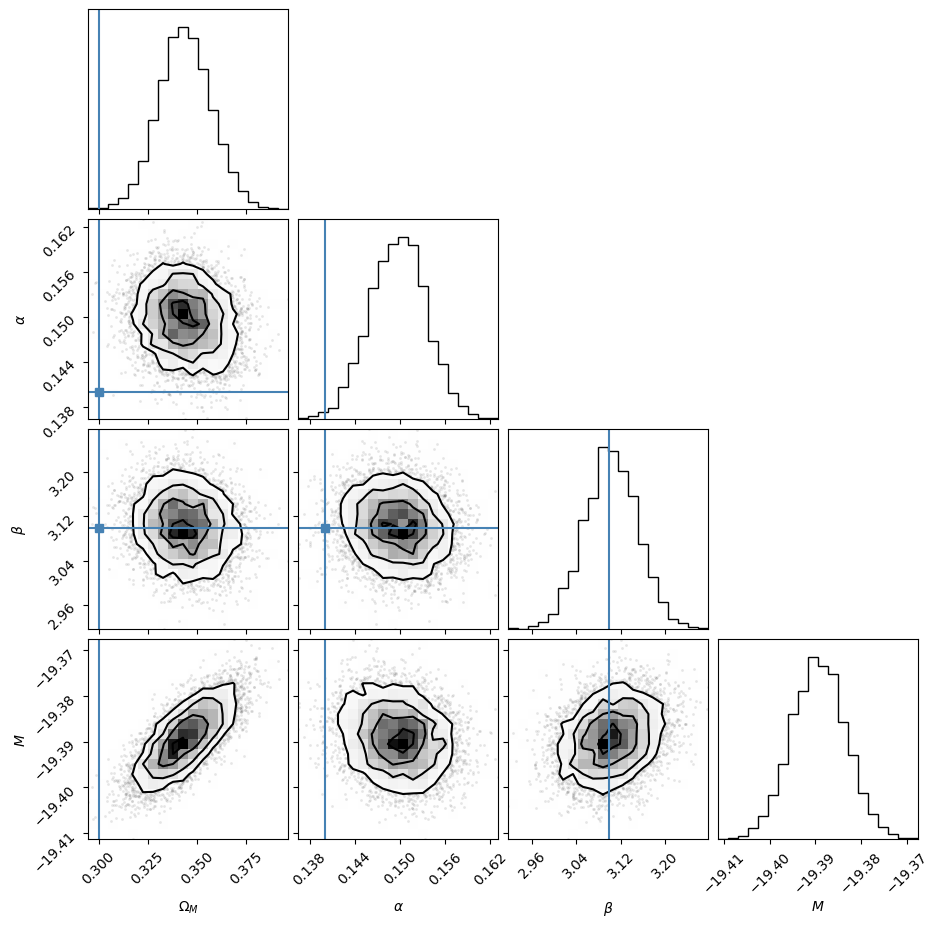

In [ ]:
#Graficamos
flat_samples = sampler.get_chain(discard=1000, thin=10, flat=True)
corner.corner(flat_samples, labels=labels, truths=theta_inicial);


In [ ]:
#Resultados
for name, samples in zip(labels, flat_samples.T):
  p16, p50, p84= np.percentile(samples, [16,50,84])
  print(f'{name}={p50:.2f} ({p16:.2f}-{p84:.2f})')

$\Omega_M$=0.34 (0.33-0.36)
$\alpha$=0.15 (0.15-0.15)
$\beta$=3.10 (3.05-3.15)
$M$=-19.39 (-19.40--19.38)


Inferencia de parámetros para un universo LCDM con curvatura  

In [ ]:
#Definimos al modelo LCDM con curvatura
#Con LambdaCDM,Astropy permite Omega_M y Omega_Lambda libres.
 #La curvatura queda como:
  # Omega_k= 1 -  Omega_M - Omega_Lambda

def modelo_LCDM_curva(z, Omega_M, Omega_Lambda):
 cosmo= LambdaCDM(H0=H0_fijo, Om0=Omega_M, Ode0=Omega_Lambda)
 mu_model= cosmo.distmod(z).value
 return mu_model



In [ ]:
#Definimos el prior para este modelo
def log_prior_curv(theta):
  Omega_M, Omega_Lambda, alpha, beta, M = theta
  if(
      0.01 < Omega_M < 1.5 and 0.0 < Omega_Lambda < 2.0 and 0.0<alpha<0.5 and 1.0<beta< 5.0 and -25<M<-15
  ):
    return 0.0
  return -np.inf


In [ ]:
#Definimos  el Likelihood , es igual pero ahora con el LCDM
def log_likelihood_curv(theta, z, cov_inv):
  Omega_M, Omega_Lambda, alpha, beta, M = theta
  #Distancias obsevadas
  mu_obs=mu_obs_tripp(alpha, beta, M)
  #Distancia predicha por el modelo cosmologico
  mu_model = modelo_LCDM_curva(z, Omega_M, Omega_Lambda)
  delta= mu_obs - mu_model
  chi2=delta.T @ cov_inv @ delta
  return  -0.5*chi2

In [ ]:
#Definimos ahora el posterior
def log_probability_curv(theta, z, cov_inv):

    lp = log_prior_curv(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood_curv(theta, z, cov_inv)

In [ ]:
#Ahora el MCMC, con curvatura
ndim_curv=5
nwalker_curv= 40
nsteps_curv= 3000

theta_inicial_curv= np.array([0.3, 0.7, 0.14, 3.1, -19.3])
pos_curv= theta_inicial_curv+ 1e-2*np.random.randn(nwalker_curv, ndim_curv)
sampler_curv= emcee.EnsembleSampler(nwalker_curv, ndim_curv, log_probability_curv, args=(z, cov_inv))
sampler_curv.run_mcmc(pos_curv, nsteps_curv, progress=True)


100%|██████████| 3000/3000 [1:09:40<00:00,  1.39s/it]


State([[  0.31026312   0.5934472    0.14956224   3.0608956  -19.38678562]
 [  0.29615796   0.62732659   0.15139634   3.09597589 -19.38955159]
 [  0.31668      0.58830058   0.15187051   3.06057284 -19.38322429]
 [  0.39929072   0.76762007   0.14658276   3.13291938 -19.40421252]
 [  0.28455853   0.57384875   0.14846706   3.06392746 -19.38504608]
 [  0.28749556   0.60730918   0.14970417   3.08337676 -19.39026488]
 [  0.33752406   0.6775702    0.14429378   3.03165506 -19.39256832]
 [  0.29735187   0.57609711   0.15100326   3.03499246 -19.38879341]
 [  0.25722917   0.58333123   0.1499175    3.26859167 -19.38065647]
 [  0.3010452    0.57129626   0.14324656   3.15327485 -19.37591634]
 [  0.37191782   0.64874468   0.15504935   3.08970933 -19.38035307]
 [  0.32002755   0.60401001   0.14904435   3.17753962 -19.38544277]
 [  0.26014294   0.5259863    0.15284372   3.08114421 -19.38170781]
 [  0.24534103   0.49022643   0.14826898   3.14089503 -19.36413394]
 [  0.36169338   0.65110914   0.15163255  

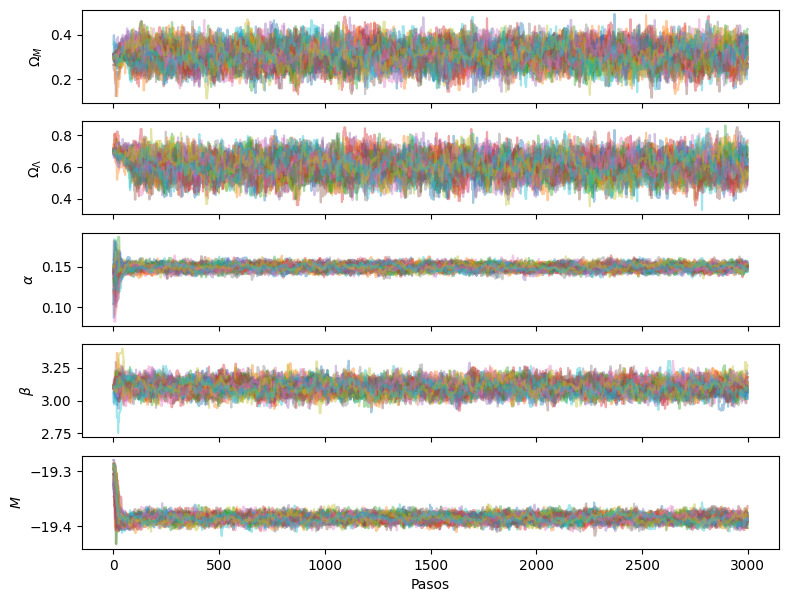

In [ ]:
#Ahora hacemos las cadenas y graficamos
samples_chain_curv=sampler_curv.get_chain()
labels_curv=[r"$\Omega_M$",
    r"$\Omega_\Lambda$",
    r"$\alpha$",
    r"$\beta$",
    r"$M$"]
fig, axes = plt.subplots(ndim_curv, figsize=(9,7), sharex=True)
for i in range(ndim_curv):
  axes[i].plot(samples_chain_curv[:,:,i],  alpha=0.4)
  axes[i].set_ylabel(labels_curv[i])
  axes[-1].set_xlabel("Pasos")
plt.show()

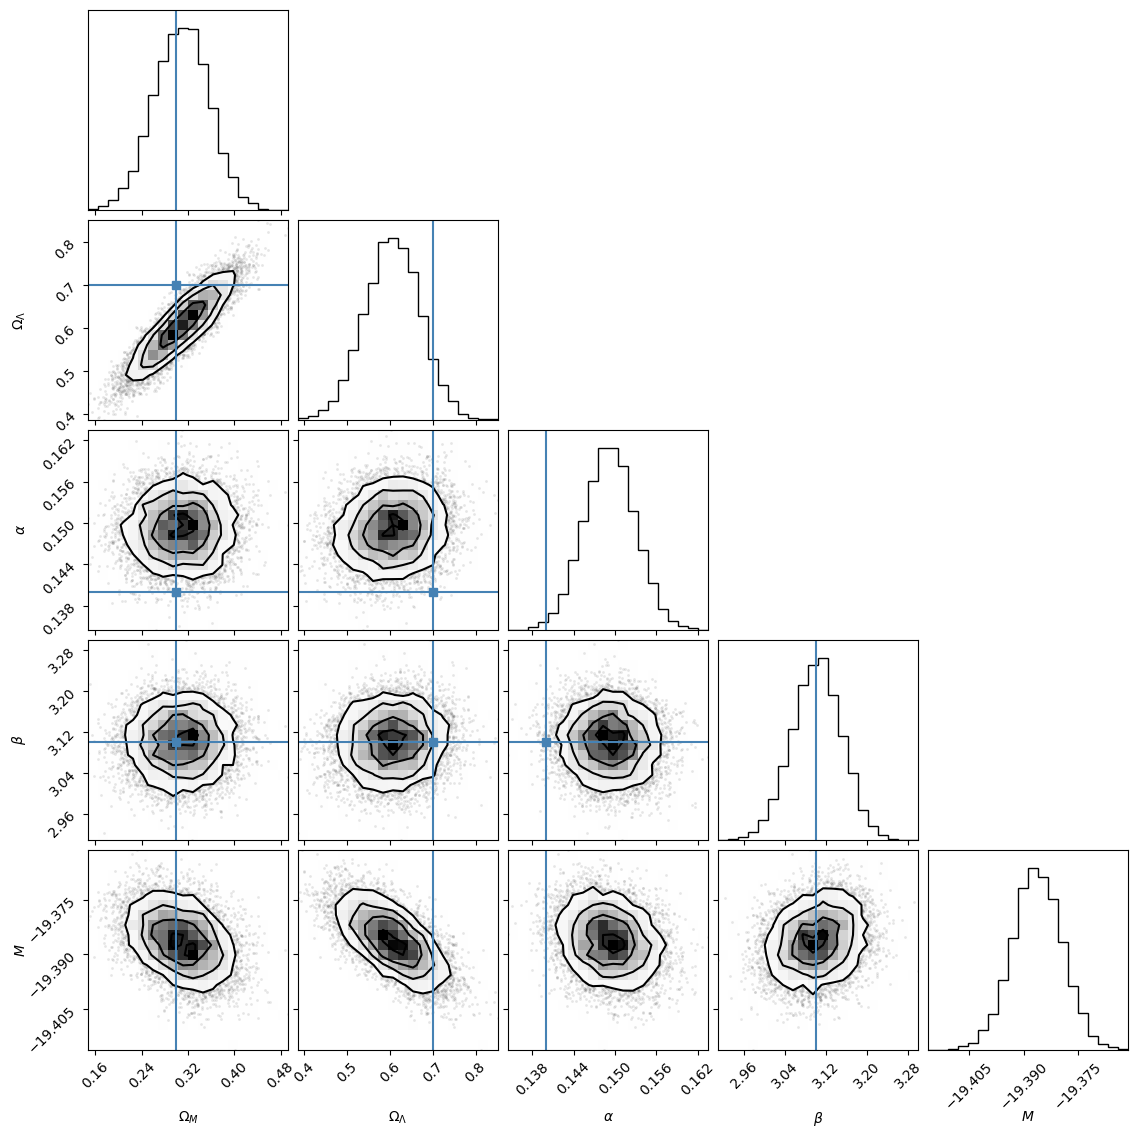

In [ ]:
#Graficamos por corner  para el LCDM con curvatura
flat_samples_curv = sampler_curv.get_chain(discard=1000, thin=10, flat=True)
corner.corner(flat_samples_curv, labels=labels_curv, truths=theta_inicial_curv)
plt.show()

In [ ]:
#Resultados para la curvatura
for name, samples in zip(labels_curv, flat_samples_curv.T):
  p16, p50, p84= np.percentile(samples, [16,50,84])
  print(f'{name}={p50:.4f} + {p84-p50:.4f}-{p50-p16:.4f}')


$\Omega_M$=0.3086 + 0.0464-0.0482
$\Omega_\Lambda$=0.6063 + 0.0631-0.0654
$\alpha$=0.1492 + 0.0038-0.0037
$\beta$=3.1027 + 0.0482-0.0494
$M$=-19.3864 + 0.0068-0.0067


In [ ]:
#Calcular omegak
Omega_M_samples = flat_samples_curv[:, 0]
Omega_Lambda_samples = flat_samples_curv[:, 1]

Omega_k_samples = 1 - Omega_M_samples - Omega_Lambda_samples

p16, p50, p84 = np.percentile(Omega_k_samples, [16, 50, 84])

print(f"Omega_k = {p50:.4f} +{p84-p50:.4f} -{p50-p16:.4f}")



Omega_k = 0.0837 +0.1127 -0.1052


 Inferencia de parámetros para un universo wCDM sin curvatura

In [ ]:
#Definimos el modelo wCDM sin curvatura, ahora tenemos  Omega_k=0 , w queda libre  y si w=-1 , regresamos a LCDM
def modelo_flat_wCDM(z, Omega_M, w):
  cosmo = FlatwCDM(H0=H0_fijo, Om0=Omega_M, w0=w)
  mu_model= cosmo.distmod(z).value
  return mu_model


In [ ]:
#Definimos  el prior
def log_prior_wCDM(theta):
   Omega_M, w, alpha, beta, M = theta
   if (
        0.01 < Omega_M < 1.0 and
        -3.0< w < 0.5 and
        0.0 < alpha < 0.5 and
        1.0 < beta < 5.0 and
        -25 < M < -15
    ):
        return 0.0
   return -np.inf


In [ ]:
#Otra vez el likelikhood
def log_likelihood_wCDM(theta, z, cov_inv):
  Omega_M, w, alpha, beta, M = theta
  #Distancias obsevadas
  mu_obs=mu_obs_tripp(alpha, beta, M)
  #Distancia predicha por el modelo cosmologico
  mu_model = modelo_flat_wCDM(z, Omega_M, w)
  delta= mu_obs - mu_model
  chi2=delta.T @ cov_inv @ delta
  return  -0.5*chi2


In [ ]:
#Igual el posterior, lo mas seguro es que pueda juntar todos en euno pero ahorita para probar
def log_probability_wCDM(theta, z, cov_inv):

    lp = log_prior_wCDM(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood_wCDM(theta, z, cov_inv)

In [ ]:
# Continuamos con el MCMC
ndim_w=5
nwalker_w= 40
nsteps_w= 3000

theta_inicial_w= np.array([0.3,-1.0, 0.14, 3.1, -19.3])
pos_w= theta_inicial_w + 1e-2*np.random.randn(nwalker_w, ndim_w)
sampler_w= emcee.EnsembleSampler(nwalker_w, ndim_w, log_probability_wCDM, args=(z, cov_inv))
sampler_w.run_mcmc(pos_w, nsteps_w, progress=True)

100%|██████████| 3000/3000 [2:04:13<00:00,  2.48s/it]


State([[  0.33705263  -0.97225071   0.1493715    3.12723561 -19.38589597]
 [  0.30151041  -0.87150922   0.1460547    3.06537453 -19.37893316]
 [  0.33266669  -0.95910441   0.15023368   3.10822094 -19.38656984]
 [  0.29315614  -0.88424429   0.15366856   3.08794399 -19.3858021 ]
 [  0.38367594  -1.13584755   0.15044745   3.17800247 -19.39610748]
 [  0.38635689  -1.09005629   0.14732362   3.10181738 -19.38964502]
 [  0.36723157  -1.10578869   0.15047189   3.18986839 -19.39589514]
 [  0.26886204  -0.86636769   0.14933686   3.05317499 -19.39558477]
 [  0.35001266  -0.99329376   0.15033574   3.04926284 -19.38915304]
 [  0.43815968  -1.27476098   0.14789184   3.08551793 -19.39309923]
 [  0.32675422  -0.97079159   0.14069916   3.18474214 -19.38514592]
 [  0.29790018  -0.88134262   0.15620592   3.11324019 -19.38692539]
 [  0.22997792  -0.79985479   0.14585468   3.15167416 -19.38550089]
 [  0.34239656  -0.95682161   0.13651055   3.16747273 -19.38085934]
 [  0.34016509  -1.03221917   0.15028669  

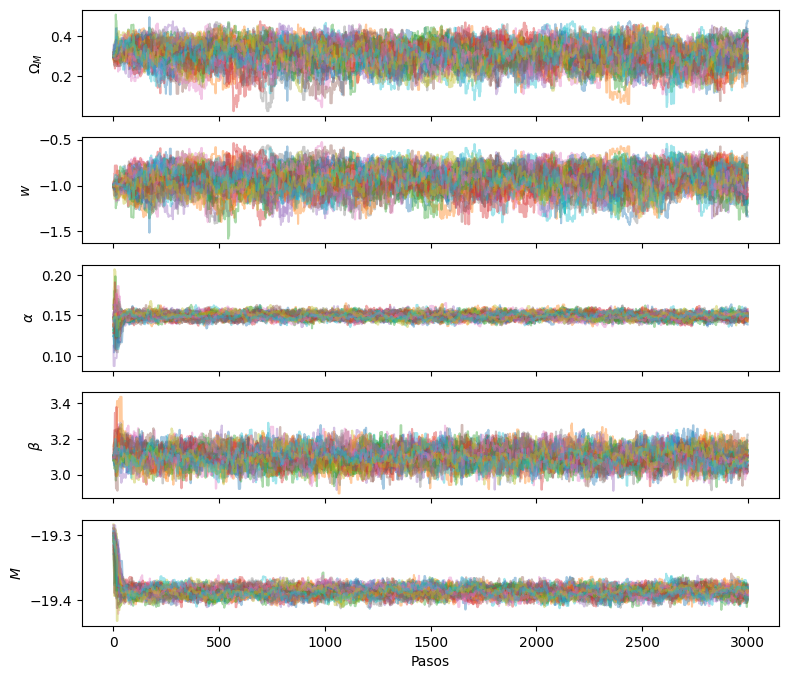

In [ ]:
#Revisamos las cadenas
samples_chain_w = sampler_w.get_chain()

labels_w = [
    r"$\Omega_M$",
    r"$w$",
    r"$\alpha$",
    r"$\beta$",
    r"$M$"
]

fig, axes = plt.subplots(
    ndim_w,
    figsize=(9, 8),
    sharex=True
)

for i in range(ndim_w):
    axes[i].plot(samples_chain_w[:, :, i], alpha=0.4)
    axes[i].set_ylabel(labels_w[i])

axes[-1].set_xlabel("Pasos")
plt.show()

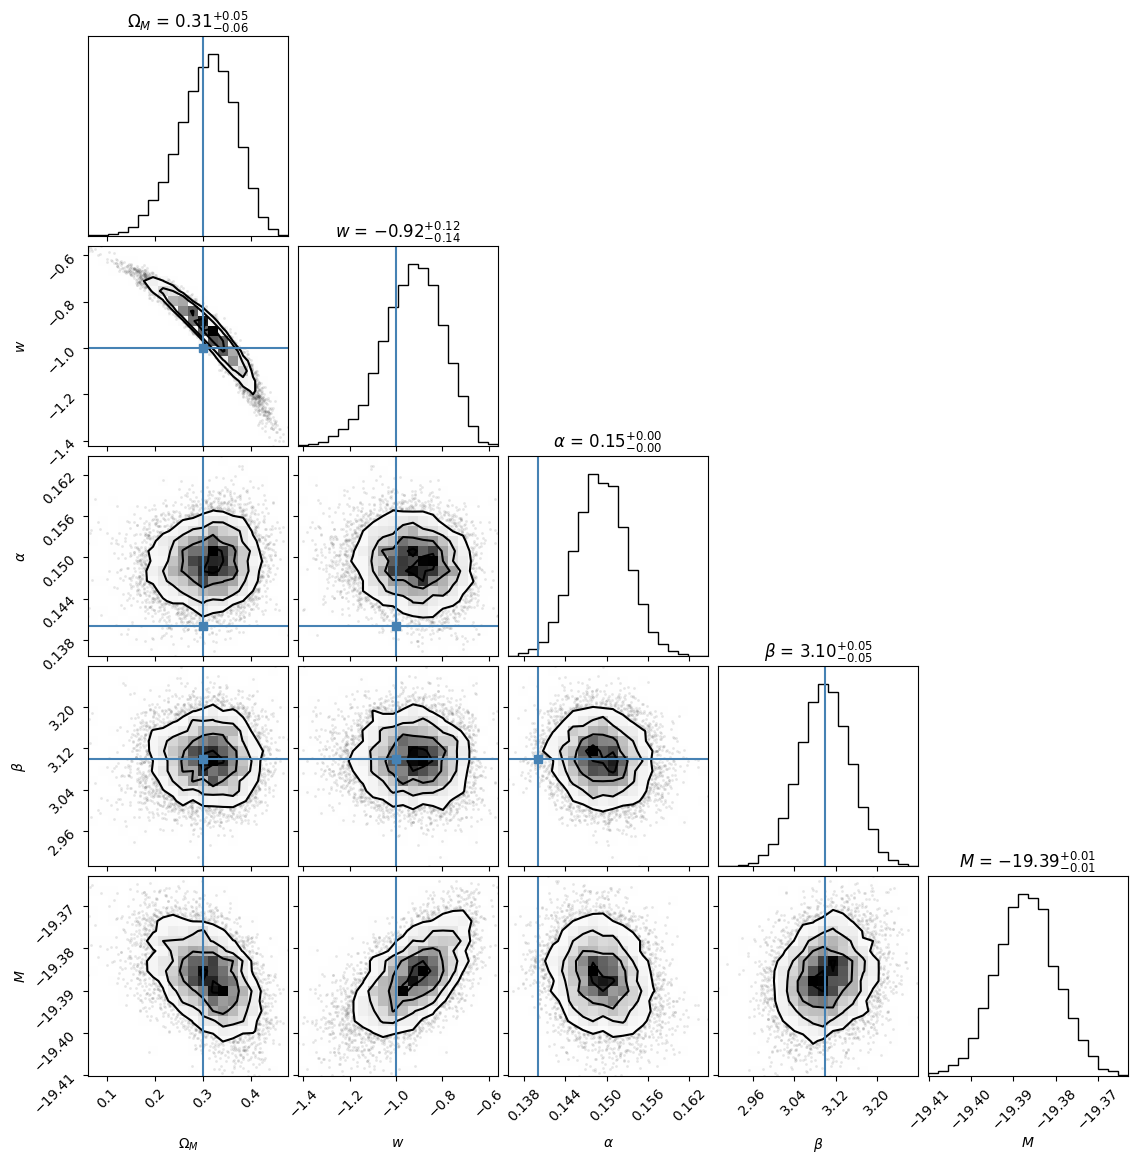

In [ ]:
#Graficamos
flat_samples_w = sampler_w.get_chain(discard=1000, thin=10, flat=True)
corner.corner(flat_samples_w, labels=labels_w, truths=[0.3, -1.0, 0.14, 3.1, -19.3],
    show_titles=True)
plt.show()


In [ ]:
#Resultados
for name, samples in zip(labels_w, flat_samples_w.T):
    p16, p50, p84 = np.percentile(samples, [16, 50, 84])
    print(f"{name} = {p50:.4f} +{p84-p50:.4f} -{p50-p16:.4f}")

$\Omega_M$ = 0.3112 +0.0546 -0.0637
$w$ = -0.9217 +0.1238 -0.1353
$\alpha$ = 0.1492 +0.0038 -0.0037
$\beta$ = 3.1001 +0.0501 -0.0492
$M$ = -19.3869 +0.0072 -0.0071


Comparativa

In [ ]:
def resumen_parametros(samples, labels, nombre_modelo):
    resultados = []

    for label, valores in zip(labels, samples.T):
        p16, p50, p84 = np.percentile(valores, [16, 50, 84])
        resultados.append({
            "Modelo": nombre_modelo,
            "Parámetro": label,
            "Mediana": p50,
            "Error -": p50 - p16,
            "Error +": p84 - p50
        })

    return resultados

In [ ]:
resultados = []

resultados += resumen_parametros(
    flat_samples,
    [r"$\Omega_M$", r"$\alpha$", r"$\beta$", r"$M$"],
    "Flat LCDM"
)

resultados += resumen_parametros(
    flat_samples_curv,
    [r"$\Omega_M$", r"$\Omega_\Lambda$", r"$\alpha$", r"$\beta$", r"$M$"],
    "LCDM con curvatura"
)

resultados += resumen_parametros(
    flat_samples_w,
    [r"$\Omega_M$", r"$w$", r"$\alpha$", r"$\beta$", r"$M$"],
    "Flat wCDM"
)

tabla_resultados = pd.DataFrame(resultados)
tabla_resultados

NameError: name 'flat_samples' is not defined

In [ ]:
for modelo in tabla_resultados["Modelo"].unique():
    print("\n", modelo)
    print(tabla_resultados[tabla_resultados["Modelo"] == modelo])


 Flat LCDM
      Modelo   Parámetro    Mediana   Error -   Error +
0  Flat LCDM  $\Omega_M$   0.343071  0.013004  0.013354
1  Flat LCDM    $\alpha$   0.149666  0.003744  0.003625
2  Flat LCDM     $\beta$   3.104865  0.049339  0.046919
3  Flat LCDM         $M$ -19.389389  0.005851  0.006032

 LCDM con curvatura
               Modelo         Parámetro    Mediana   Error -   Error +
4  LCDM con curvatura        $\Omega_M$   0.308353  0.045500  0.047674
5  LCDM con curvatura  $\Omega_\Lambda$   0.611188  0.067722  0.065209
6  LCDM con curvatura          $\alpha$   0.149405  0.003743  0.003706
7  LCDM con curvatura           $\beta$   3.104294  0.047552  0.047781
8  LCDM con curvatura               $M$ -19.386680  0.007195  0.007017

 Flat wCDM
       Modelo   Parámetro    Mediana   Error -   Error +
9   Flat wCDM  $\Omega_M$   0.311174  0.063714  0.054592
10  Flat wCDM         $w$  -0.921736  0.135263  0.123752
11  Flat wCDM    $\alpha$   0.149153  0.003723  0.003787
12  Flat wCDM     $\b

In [ ]:
Omega_k_curv = 1 - flat_samples_curv[:,0] - flat_samples_curv[:,1]

p16, p50, p84 = np.percentile(Omega_k_curv, [16, 50, 84])

print(f"Omega_k = {p50:.4f} +{p84-p50:.4f} -{p50-p16:.4f}")

Omega_k = 0.0796 +0.1112 -0.1091


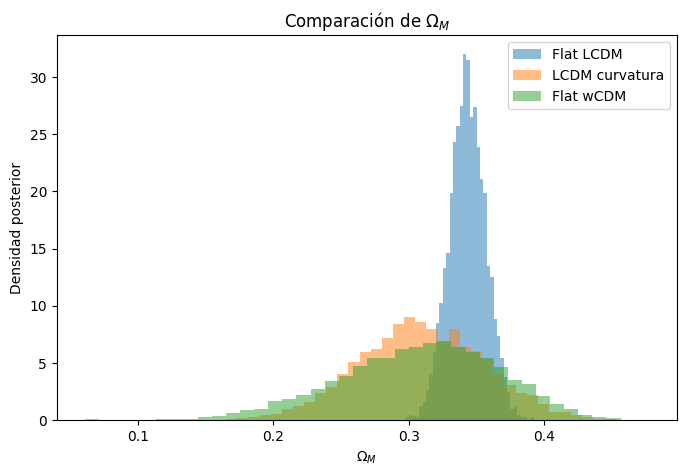

In [ ]:
OmegaM_flat = flat_samples[:,0]
OmegaM_curv = flat_samples_curv[:,0]
OmegaM_w = flat_samples_w[:,0]

plt.figure(figsize=(8,5))

plt.hist(OmegaM_flat, bins=40, density=True, alpha=0.5, label="Flat LCDM")
plt.hist(OmegaM_curv, bins=40, density=True, alpha=0.5, label="LCDM curvatura")
plt.hist(OmegaM_w, bins=40, density=True, alpha=0.5, label="Flat wCDM")

plt.xlabel(r"$\Omega_M$")
plt.ylabel("Densidad posterior")
plt.legend()
plt.title(r"Comparación de $\Omega_M$")
plt.show()

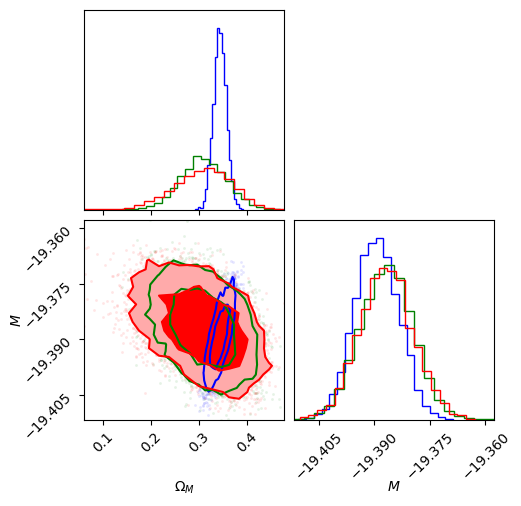

In [ ]:
figure = corner.corner(
    flat_samples[:, [0,3]],
    labels=[r"$\Omega_M$", r"$M$"],
    color="blue",
    levels=(0.68, 0.95),
    plot_density=False,
    fill_contours=True,
    hist_kwargs={"density": True}
)

corner.corner(
    flat_samples_curv[:, [0,4]],
    labels=[r"$\Omega_M$", r"$M$"],
    color="green",
    levels=(0.68, 0.95),
    plot_density=False,
    fill_contours=True,
    hist_kwargs={"density": True},
    fig=figure
)

corner.corner(
    flat_samples_w[:, [0,4]],
    labels=[r"$\Omega_M$", r"$M$"],
    color="red",
    levels=(0.68, 0.95),
    plot_density=False,
    fill_contours=True,
    hist_kwargs={"density": True},
    fig=figure
)

plt.show()

Criterios AIC y BIC


In [ ]:
#Definimos la funcion para calcular dichos criterios
def calcular_AIC_BIC(loglike_max, k, N):
    AIC = 2 * k - 2 * loglike_max
    BIC = np.log(N) * k - 2 * loglike_max
    return AIC, BIC

In [ ]:
#Definimos loglike max para flat LCDM

loglikes_flat = np.array([
    log_likelihood(sample, z, cov_inv)
    for sample in flat_samples
])

loglike_max_flat = np.max(loglikes_flat)

AIC_flat, BIC_flat = calcular_AIC_BIC(
    loglike_max_flat,
    k=4,
    N=len(z)
)

In [ ]:
#Definimos loglike max para LCDM con curvatura
loglikes_curv = np.array([
    log_likelihood_curv(sample, z, cov_inv)
    for sample in flat_samples_curv
])

loglike_max_curv = np.max(loglikes_curv)

AIC_curv, BIC_curv = calcular_AIC_BIC(
    loglike_max_curv,
    k=5,
    N=len(z)
)

In [ ]:
loglikes_w = np.array([
    log_likelihood_wCDM(sample, z, cov_inv)
    for sample in flat_samples_w
])

loglike_max_w = np.max(loglikes_w)

AIC_w, BIC_w = calcular_AIC_BIC(
    loglike_max_w,
    k=5,
    N=len(z)
)

In [ ]:
#Tabla compartiva
comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Flat LCDM",
        "LCDM con curvatura",
        "Flat wCDM"
    ],
    "k": [4, 5, 5],
    "logL_max": [
        loglike_max_flat,
        loglike_max_curv,
        loglike_max_w
    ],
    "AIC": [
        AIC_flat,
        AIC_curv,
        AIC_w
    ],
    "BIC": [
        BIC_flat,
        BIC_curv,
        BIC_w
    ]
})

comparacion_modelos["Delta_AIC"] = (
    comparacion_modelos["AIC"] - comparacion_modelos["AIC"].min()
)

comparacion_modelos["Delta_BIC"] = (
    comparacion_modelos["BIC"] - comparacion_modelos["BIC"].min()
)

comparacion_modelos